# Credit Card Approval Prediction System

## APSCHE SmartBridge Virtual Internship

### Project Title
**Credit Card Approval Prediction**

### Objective

The objective of this project is to develop a Machine Learning model that predicts whether a credit card application should be approved or rejected based on an applicant's demographic and credit history information.

This project follows the complete Machine Learning pipeline, including:

- Data Collection
- Data Cleaning
- Data Merging
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Model Saving
- Flask Web Application Development

---

# Epic 1: Data Collection

## Description

The project uses two datasets:

1. **application_record.csv**
   - Contains applicant demographic and financial details.

2. **credit_record.csv**
   - Contains applicant credit history.

Both datasets share a common column named **ID**, which will be used later for merging the datasets.

# Step 1: Import Required Libraries

In [2]:
# Ignore unnecessary warning messages

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import libraries for data manipulation

import numpy as np
import pandas as pd

# Import libraries for data visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Import preprocessing libraries

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Import Machine Learning models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



In [4]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [5]:
# Import Pickle library for saving the trained model

import pickle

# Step 2: Load the Datasets

## Description

In this step, both datasets are loaded into the notebook.

The application dataset contains applicant details, whereas the credit dataset contains applicant credit history.

These datasets will later be merged using the common **ID** column.

In [6]:
# Load the application dataset

application = pd.read_csv("../Dataset/application_record.csv")

# Load the credit history dataset

credit = pd.read_csv("../Dataset/credit_record.csv")

# Step 3: Display the Datasets

## Description

Before preprocessing the data, it is important to inspect the first few records of each dataset.

This helps in understanding the structure, available features, and the type of information stored in each dataset.

In [7]:
# Display the first five records of the application dataset

application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [8]:
# Display the first five records of the credit history dataset

credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


# Step 4: Dataset Dimensions

## Description

The shape of a dataset provides the number of rows and columns.

Knowing the dataset dimensions helps estimate the amount of data available for analysis and model building.

In [9]:
# Display the number of rows and columns in both datasets

print("Application Dataset Shape :", application.shape)
print("Credit Dataset Shape      :", credit.shape)

Application Dataset Shape : (438557, 18)
Credit Dataset Shape      : (1048575, 3)


## Observations

- Successfully loaded both datasets.
- The application dataset contains applicant demographic and financial information.
- The credit dataset contains historical credit records.
- Both datasets contain the **ID** column, which will be used later for merging.

# Step 5: Understanding the Dataset

## Description

Before performing data preprocessing, it is essential to understand the structure of the datasets.

This includes:
- Number of records
- Data types
- Missing values
- Available features

In [10]:
# Display information about the application dataset

application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [11]:
# Display information about the credit history dataset

credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [12]:
# Display the statistical summary of the application dataset

application.describe(include="all")

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
count,4.385570e+05,438557,438557,438557,438557.000000,4.385570e+05,438557,438557,438557,438557,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,304354,438557.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,Laborers,NaN
freq,NaN,294440,275459,304074,NaN,NaN,226104,301821,299828,393831,NaN,NaN,NaN,NaN,NaN,NaN,78240,NaN
mean,6.022176e+06,NaN,NaN,NaN,0.427390,1.875243e+05,NaN,NaN,NaN,NaN,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,NaN,2.194465
std,5.716370e+05,NaN,NaN,NaN,0.724882,1.100869e+05,NaN,NaN,NaN,NaN,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,NaN,0.897207
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.610000e+04,NaN,NaN,NaN,NaN,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,NaN,1.000000
25%,5.609375e+06,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
50%,6.047745e+06,NaN,NaN,NaN,0.000000,1.607805e+05,NaN,NaN,NaN,NaN,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
75%,6.456971e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,NaN,3.000000


In [13]:
# Display the statistical summary of the credit history dataset

credit.describe(include="all")

,ID,MONTHS_BALANCE,STATUS
count,1.048575e+06,1.048575e+06,1048575
unique,NaN,NaN,8
top,NaN,NaN,C
freq,NaN,NaN,442031
mean,5.068286e+06,-1.913700e+01,NaN
std,4.615058e+04,1.402350e+01,NaN
min,5.001711e+06,-6.000000e+01,NaN
25%,5.023644e+06,-2.900000e+01,NaN
50%,5.062104e+06,-1.700000e+01,NaN
75%,5.113856e+06,-7.000000e+00,NaN


# Step 6: Missing Value Analysis

## Description

Missing values can affect the performance of Machine Learning models.

In this step, we identify columns containing missing values so that appropriate preprocessing techniques can be applied.

In [14]:
# Check missing values in the application dataset

application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [15]:
# Check missing values in the credit history dataset

credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

## Observations

- Missing values have been identified in both datasets.
- These missing values will be handled during the data preprocessing phase.
- Understanding missing data helps improve model performance and data quality.

# Epic 2: Data Preprocessing

## Description

Data preprocessing is one of the most important phases of any Machine Learning project.

The raw datasets may contain missing values, duplicate records, unnecessary features, and inconsistent data formats. These issues can negatively affect model performance.

In this phase, we will:

- Check duplicate records
- Handle missing values
- Merge both datasets
- Create the target variable
- Perform feature engineering
- Prepare the dataset for model building

# Step 7: Checking Duplicate Records

## Description

Duplicate records increase redundancy and may introduce bias into the Machine Learning model.

Therefore, duplicate rows are identified before further preprocessing.

In [16]:
# Check duplicate rows in the application dataset

print("Duplicate rows in Application Dataset :", application.duplicated().sum())

Duplicate rows in Application Dataset : 0


In [17]:
# Check duplicate rows in the credit dataset

print("Duplicate rows in Credit Dataset :", credit.duplicated().sum())

Duplicate rows in Credit Dataset : 0


## Observations

- No duplicate records were found in either dataset.
- Both datasets are free from redundant entries.
- Therefore, no duplicate removal is required before further preprocessing.

# Step 8: Handling Missing Values

## Description

Missing values can reduce the quality of a Machine Learning model if they are not handled properly.

From the previous analysis, it was observed that only the **OCCUPATION_TYPE** column contains missing values in the application dataset.

In this step, we will analyze the missing values and replace them with an appropriate value.

In [18]:
# Display missing values in descending order

application.isnull().sum().sort_values(ascending=False)

OCCUPATION_TYPE        134203
ID                          0
CODE_GENDER                 0
FLAG_EMAIL                  0
FLAG_PHONE                  0
FLAG_WORK_PHONE             0
FLAG_MOBIL                  0
DAYS_EMPLOYED               0
DAYS_BIRTH                  0
NAME_HOUSING_TYPE           0
NAME_FAMILY_STATUS          0
NAME_EDUCATION_TYPE         0
NAME_INCOME_TYPE            0
AMT_INCOME_TOTAL            0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
FLAG_OWN_CAR                0
CNT_FAM_MEMBERS             0
dtype: int64

In [19]:
# Calculate the percentage of missing values

missing_percentage = (application.isnull().sum() / len(application)) * 100

missing_percentage.sort_values(ascending=False)

OCCUPATION_TYPE        30.601039
ID                      0.000000
CODE_GENDER             0.000000
FLAG_EMAIL              0.000000
FLAG_PHONE              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_MOBIL              0.000000
DAYS_EMPLOYED           0.000000
DAYS_BIRTH              0.000000
NAME_HOUSING_TYPE       0.000000
NAME_FAMILY_STATUS      0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_INCOME_TYPE        0.000000
AMT_INCOME_TOTAL        0.000000
CNT_CHILDREN            0.000000
FLAG_OWN_REALTY         0.000000
FLAG_OWN_CAR            0.000000
CNT_FAM_MEMBERS         0.000000
dtype: float64

In [20]:
# Replace missing values in OCCUPATION_TYPE with "Unknown"

application["OCCUPATION_TYPE"].fillna("Unknown", inplace=True)

In [21]:
# Verify that missing values have been handled

application.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
dtype: int64

## Observations

- The **OCCUPATION_TYPE** column contained missing values.
- Missing values were replaced with **"Unknown"** instead of deleting the records.
- This approach preserves all applicant records while ensuring there are no missing values in the dataset.

# Step 9: Data Merging

## Description

The project consists of two separate datasets:

- **Application Dataset:** Contains applicant demographic and financial information.
- **Credit Dataset:** Contains historical credit repayment records.

These datasets are linked through the common **ID** column.

Before merging, the credit history must be converted into a single approval status for each applicant. This status will become the target variable used for machine learning.

In [22]:
# Display unique values present in the STATUS column

credit["STATUS"].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

## Understanding the STATUS Column

The **STATUS** column represents the repayment history of each applicant.

Meaning of values:

- X → No loan for the month
- C → Loan closed
- 0 → Paid on time
- 1 → 1–29 days overdue
- 2 → 30–59 days overdue
- 3 → 60–89 days overdue
- 4 → 90–119 days overdue
- 5 → More than 120 days overdue

Applicants having repayment status **2, 3, 4, or 5** are considered **high-risk** and their applications will be marked as **Rejected (1)**.

Applicants with repayment status **X, C, 0, or 1** are considered **low-risk** and will be marked as **Approved (0)**.

In [23]:
# Create the target variable from credit history

credit["TARGET"] = credit["STATUS"].apply(
    lambda x: 1 if x in ["2", "3", "4", "5"] else 0
)

In [24]:
# Display the first five rows after creating the target variable

credit.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


In [25]:
# Group records by applicant ID

credit_grouped = credit.groupby("ID")["TARGET"].max().reset_index()

In [26]:
# Display the grouped dataset

credit_grouped.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [27]:
# Merge application and credit datasets using the common ID column

data = application.merge(credit_grouped, on="ID", how="inner")

In [28]:
# Display the shape of the merged dataset

print("Merged Dataset Shape :", data.shape)

Merged Dataset Shape : (36457, 19)


In [29]:
# Display the first five rows of the merged dataset

data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


## Observations

- The target variable was successfully created using the applicant's credit repayment history.
- Multiple monthly credit records were aggregated into a single record for each applicant.
- Both datasets were successfully merged using the common **ID** column.
- The merged dataset contains **36,457 rows** and **19 columns**.
- This dataset is now ready for feature engineering and machine learning.

# Step 10: Feature Engineering

## Description

Feature engineering is the process of transforming existing features into more meaningful representations that improve the performance of machine learning models.

In this project, we will:

- Convert age from days to years.
- Convert employment duration from days to years.
- Remove unnecessary columns.
- Prepare the dataset for encoding.

In [30]:
# Create applicant age in years

data["AGE"] = (-data["DAYS_BIRTH"] / 365).astype(int)

In [31]:
# Convert employment duration from days to years

data["YEARS_EMPLOYED"] = data["DAYS_EMPLOYED"].apply(
    lambda x: 0 if x > 0 else abs(x) / 365
)

In [32]:
# Display the first five rows

data[["DAYS_BIRTH", "AGE", "DAYS_EMPLOYED", "YEARS_EMPLOYED"]].head()

,DAYS_BIRTH,AGE,DAYS_EMPLOYED,YEARS_EMPLOYED
0,-12005,32,-4542,12.443836
1,-12005,32,-4542,12.443836
2,-21474,58,-1134,3.106849
3,-19110,52,-3051,8.358904
4,-19110,52,-3051,8.358904


In [33]:
# Remove unnecessary columns

data.drop(columns=["ID", "DAYS_BIRTH", "DAYS_EMPLOYED"], inplace=True)

In [34]:
# Display dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   FLAG_MOBIL           36457 non-null  int64  
 10  FLAG_WORK_PHONE      36457 non-null  int64  
 11  FLAG_PHONE           36457 non-null  int64  
 12  FLAG_EMAIL           36457 non-null  int64  
 13  OCCUPATION_TYPE      36457 non-null  object 
 14  CNT_FAM_MEMBERS      36457 non-null  float64
 15  TARGET               36457 non-null 

## Observations

- Applicant age was successfully converted from days to years.
- Employment duration was converted into years for easier interpretation.
- The **ID** column was removed because it is only an identifier and does not contribute to prediction.
- The original day-based columns were removed after creating more meaningful features.

# Step 11: Verify the Processed Dataset

## Description

After feature engineering, it is important to verify the structure of the processed dataset.

This step confirms that:
- New features have been created successfully.
- Unnecessary columns have been removed.
- The dataset is ready for exploratory data analysis.

In [35]:
# Display the first five rows of the processed dataset

data.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,0,32,12.443836
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,0,32,12.443836
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,0,58,3.106849
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8.358904
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,0,52,8.358904


In [36]:
# Display the dimensions of the processed dataset

print("Processed Dataset Shape :", data.shape)

Processed Dataset Shape : (36457, 18)


In [37]:
# Display dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CODE_GENDER          36457 non-null  object 
 1   FLAG_OWN_CAR         36457 non-null  object 
 2   FLAG_OWN_REALTY      36457 non-null  object 
 3   CNT_CHILDREN         36457 non-null  int64  
 4   AMT_INCOME_TOTAL     36457 non-null  float64
 5   NAME_INCOME_TYPE     36457 non-null  object 
 6   NAME_EDUCATION_TYPE  36457 non-null  object 
 7   NAME_FAMILY_STATUS   36457 non-null  object 
 8   NAME_HOUSING_TYPE    36457 non-null  object 
 9   FLAG_MOBIL           36457 non-null  int64  
 10  FLAG_WORK_PHONE      36457 non-null  int64  
 11  FLAG_PHONE           36457 non-null  int64  
 12  FLAG_EMAIL           36457 non-null  int64  
 13  OCCUPATION_TYPE      36457 non-null  object 
 14  CNT_FAM_MEMBERS      36457 non-null  float64
 15  TARGET               36457 non-null 

## Observations

- The processed dataset contains applicant information along with the target variable.
- New features such as **AGE** and **YEARS_EMPLOYED** were successfully created.
- Unnecessary columns were removed.
- The dataset is now ready for exploratory data analysis and model development.

# Epic 3: Exploratory Data Analysis (EDA)

## Description

Exploratory Data Analysis (EDA) is performed to better understand the characteristics of the dataset before building Machine Learning models.

In this phase, we will perform:

- Descriptive Analysis
- Univariate Analysis
- Multivariate Analysis

The insights gained from EDA help in identifying patterns, relationships, and important features that influence credit card approval.

# Step 12: Descriptive Analysis

## Description

Descriptive analysis provides a statistical summary of the dataset. It helps us understand the central tendency, spread, and distribution of numerical features before model training.

In [38]:
# Display statistical summary of numerical features

data.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
count,36457.000000,3.645700e+04,36457.0,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,0.430315,1.866857e+05,1.0,0.225526,0.294813,0.089722,2.198453,0.016897,43.260334,6.028266
std,0.742367,1.017892e+05,0.0,0.417934,0.455965,0.285787,0.911686,0.128886,11.510414,6.484375
min,0.000000,2.700000e+04,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.000000
25%,0.000000,1.215000e+05,1.0,0.000000,0.000000,0.000000,2.000000,0.000000,34.000000,1.117808
50%,0.000000,1.575000e+05,1.0,0.000000,0.000000,0.000000,2.000000,0.000000,42.000000,4.252055
75%,1.000000,2.250000e+05,1.0,0.000000,1.000000,0.000000,3.000000,0.000000,53.000000,8.638356
max,19.000000,1.575000e+06,1.0,1.000000,1.000000,1.000000,20.000000,1.000000,68.000000,43.049315


In [39]:
# Display statistical summary including categorical features

data.describe(include="all")

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
count,36457,36457,36457,36457.000000,3.645700e+04,36457,36457,36457,36457,36457.0,36457.000000,36457.000000,36457.000000,36457,36457.000000,36457.000000,36457.000000,36457.000000
unique,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,19,NaN,NaN,NaN,NaN
top,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN
freq,24430,22614,24506,NaN,NaN,18819,24777,25048,32548,NaN,NaN,NaN,NaN,11323,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.430315,1.866857e+05,NaN,NaN,NaN,NaN,1.0,0.225526,0.294813,0.089722,NaN,2.198453,0.016897,43.260334,6.028266
std,NaN,NaN,NaN,0.742367,1.017892e+05,NaN,NaN,NaN,NaN,0.0,0.417934,0.455965,0.285787,NaN,0.911686,0.128886,11.510414,6.484375
min,NaN,NaN,NaN,0.000000,2.700000e+04,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,20.000000,0.000000
25%,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,NaN,2.000000,0.000000,34.000000,1.117808
50%,NaN,NaN,NaN,0.000000,1.575000e+05,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,NaN,2.000000,0.000000,42.000000,4.252055
75%,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,1.0,0.000000,1.000000,0.000000,NaN,3.000000,0.000000,53.000000,8.638356


In [40]:
# Display data types of all features

data.dtypes

CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
TARGET                   int64
AGE                      int64
YEARS_EMPLOYED         float64
dtype: object

In [41]:
# Count numerical and categorical columns

numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = data.select_dtypes(include=["object"]).columns

print("Number of Numerical Features :", len(numerical_columns))
print("Number of Categorical Features :", len(categorical_columns))

Number of Numerical Features : 10
Number of Categorical Features : 8


In [42]:
# Display numerical and categorical feature names

print("Numerical Features:\n")
print(list(numerical_columns))

print("\nCategorical Features:\n")
print(list(categorical_columns))

Numerical Features:

['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'TARGET', 'AGE', 'YEARS_EMPLOYED']

Categorical Features:

['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


## Observations

- The dataset contains both numerical and categorical features.
- Numerical features include applicant income, number of children, family members, age, years employed, and the target variable.
- Categorical features include gender, education, income type, family status, housing type, occupation, and ownership information.
- Understanding feature types helps determine appropriate preprocessing techniques before model training.

# Step 13: Univariate Analysis

## Description

Univariate analysis studies one feature at a time.

This analysis helps understand the distribution, frequency, and characteristics of individual variables present in the dataset.

In [43]:
# Import matplotlib for visualization

import matplotlib.pyplot as plt

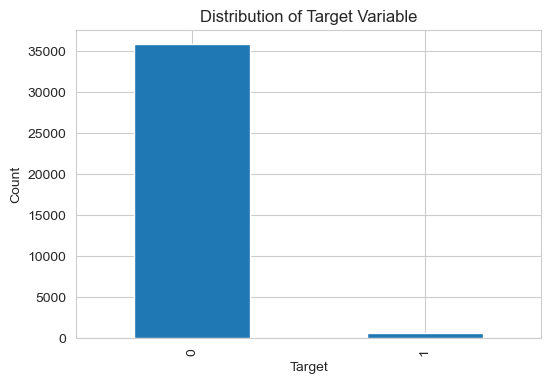

In [44]:
# Distribution of the Target Variable

plt.figure(figsize=(6,4))
data["TARGET"].value_counts().plot(kind="bar")

plt.title("Distribution of Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

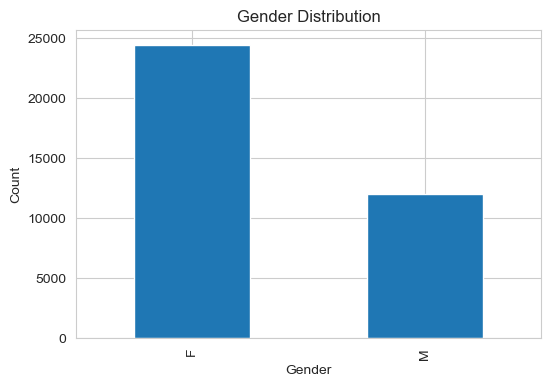

In [45]:
# Gender Distribution

plt.figure(figsize=(6,4))
data["CODE_GENDER"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

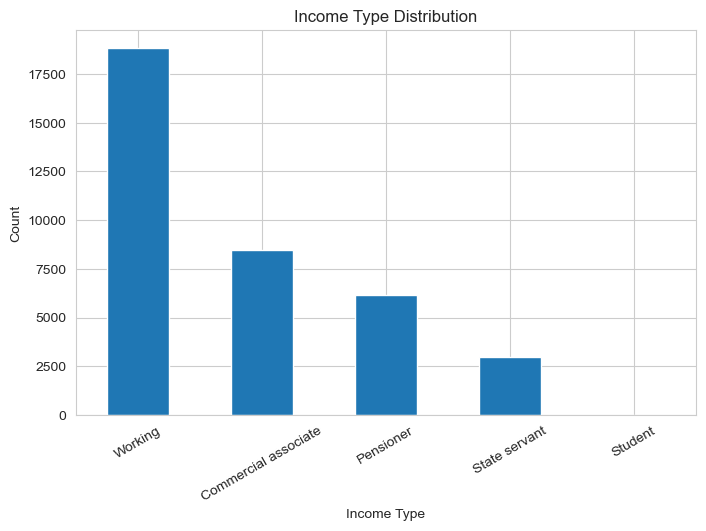

In [46]:
# Income Type Distribution

plt.figure(figsize=(8,5))
data["NAME_INCOME_TYPE"].value_counts().plot(kind="bar")

plt.title("Income Type Distribution")
plt.xlabel("Income Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.show()

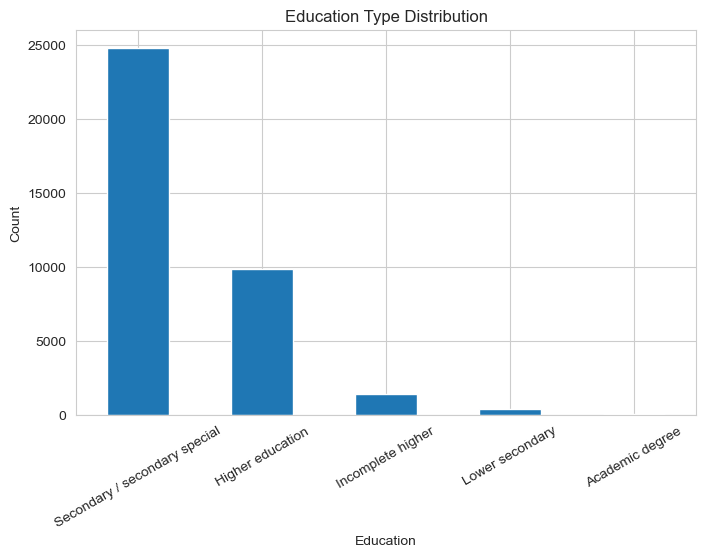

In [47]:
# Education Type Distribution

plt.figure(figsize=(8,5))
data["NAME_EDUCATION_TYPE"].value_counts().plot(kind="bar")

plt.title("Education Type Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.show()

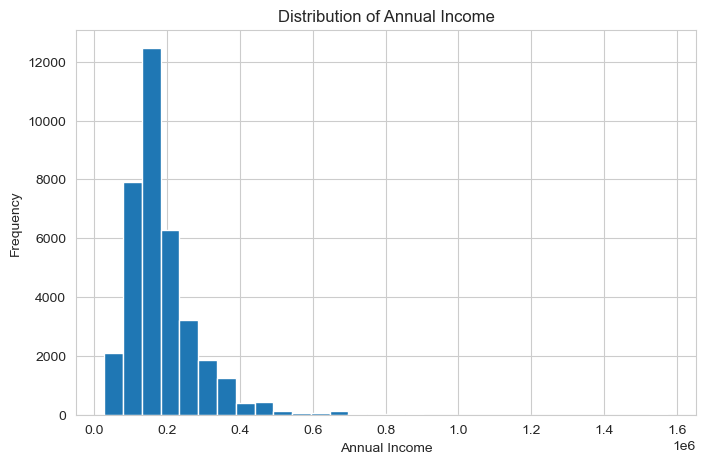

In [48]:
# Distribution of Annual Income

plt.figure(figsize=(8,5))

plt.hist(data["AMT_INCOME_TOTAL"], bins=30)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

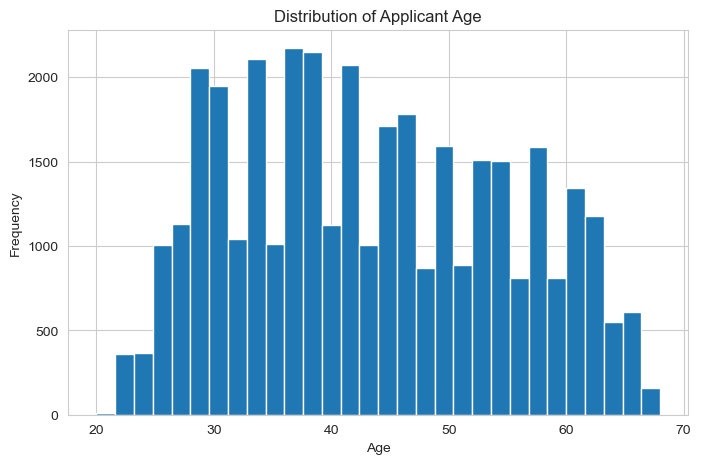

In [49]:
# Distribution of Applicant Age

plt.figure(figsize=(8,5))

plt.hist(data["AGE"], bins=30)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Observations

- The target variable shows the distribution of approved and rejected applications.
- The applicant population consists of both male and female applicants.
- Different income groups are represented in the dataset.
- Applicants possess varying educational backgrounds.
- Annual income and age distributions provide insights into the demographic characteristics of applicants.

# Step 14: Multivariate Analysis

## Description

Multivariate analysis examines the relationship between two or more variables.

This analysis helps identify patterns, feature relationships, and variables that may influence the target variable. Understanding these relationships is useful for selecting meaningful features before model building.

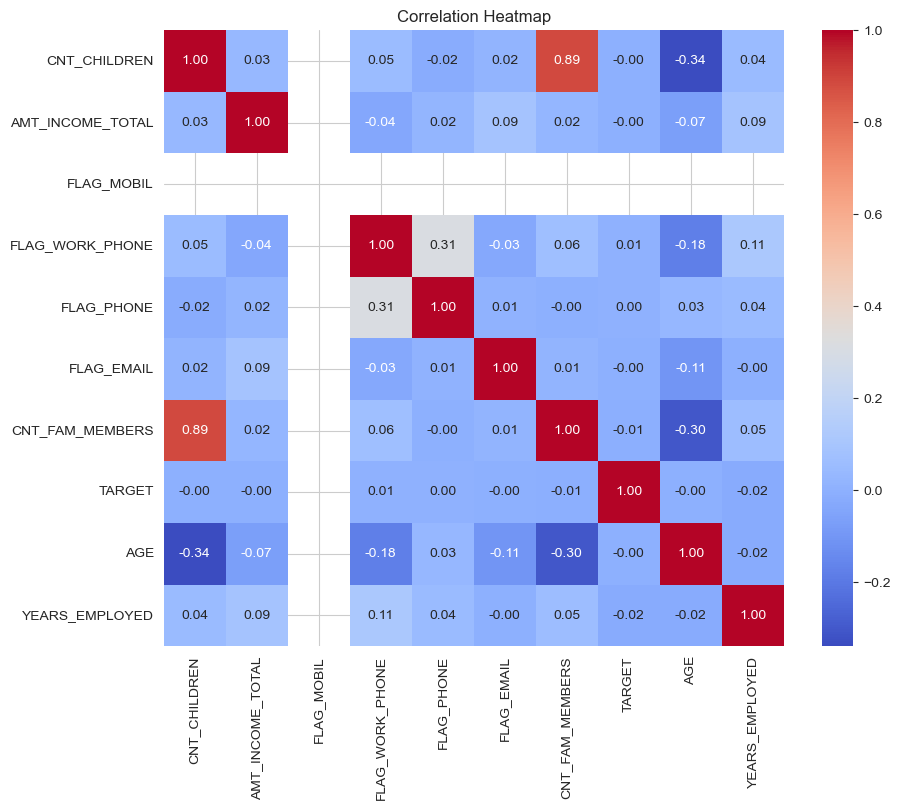

In [50]:
# Select only numerical columns

numerical_data = data.select_dtypes(include=["int64", "float64"])

# Plot correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    numerical_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

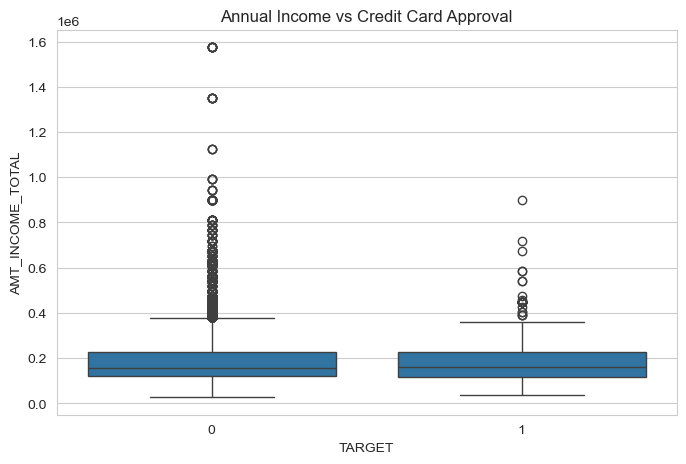

In [53]:
# Annual Income vs Target

plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="AMT_INCOME_TOTAL",
    data=data
)

plt.title("Annual Income vs Credit Card Approval")

plt.show()

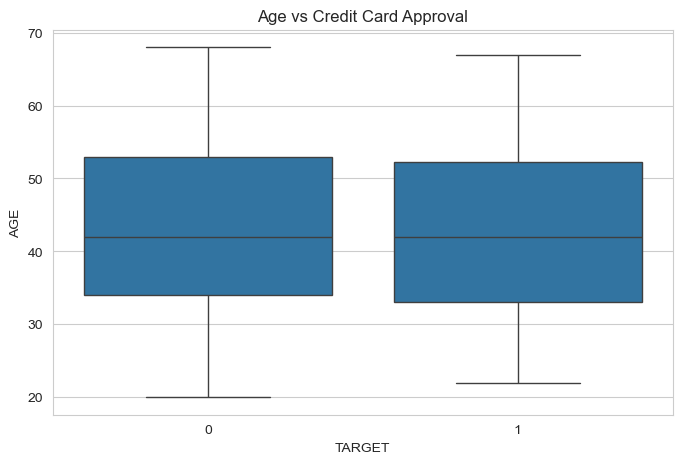

In [54]:
# Applicant Age vs Target

plt.figure(figsize=(8,5))

sns.boxplot(
    x="TARGET",
    y="AGE",
    data=data
)

plt.title("Age vs Credit Card Approval")

plt.show()

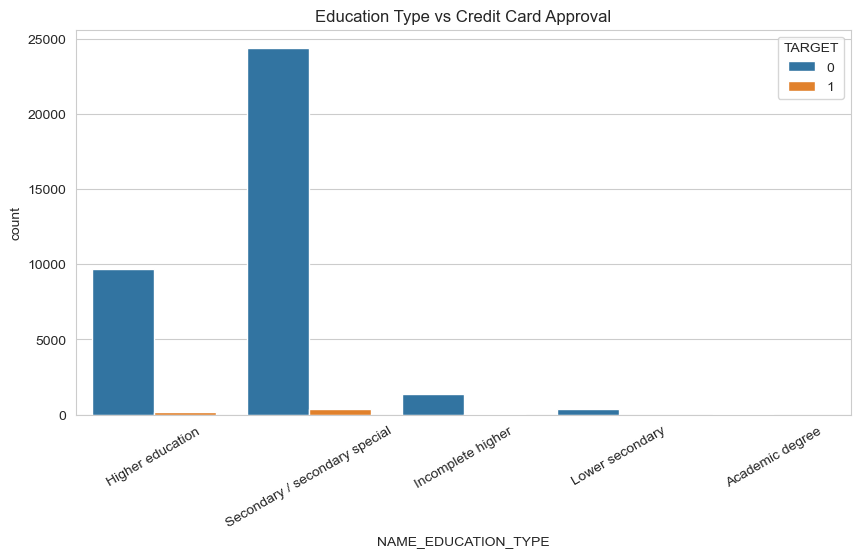

In [55]:
# Education Type vs Target

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="NAME_EDUCATION_TYPE",
    hue="TARGET"
)

plt.xticks(rotation=30)

plt.title("Education Type vs Credit Card Approval")

plt.show()

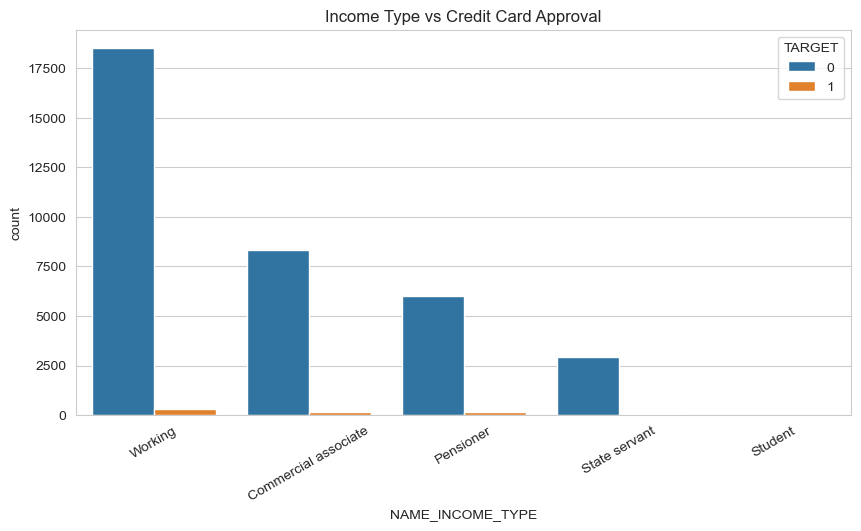

In [56]:
# Income Type vs Target

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="NAME_INCOME_TYPE",
    hue="TARGET"
)

plt.xticks(rotation=30)

plt.title("Income Type vs Credit Card Approval")

plt.show()

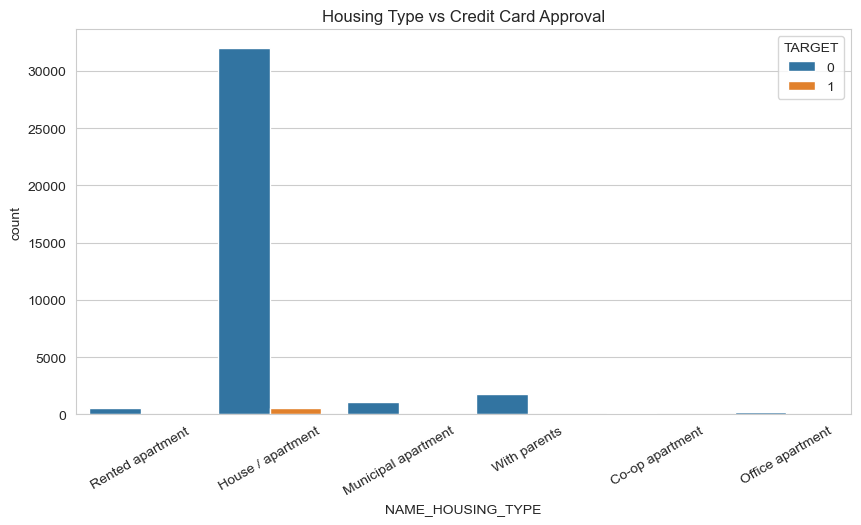

In [57]:
# Housing Type vs Target

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="NAME_HOUSING_TYPE",
    hue="TARGET"
)

plt.xticks(rotation=30)

plt.title("Housing Type vs Credit Card Approval")

plt.show()

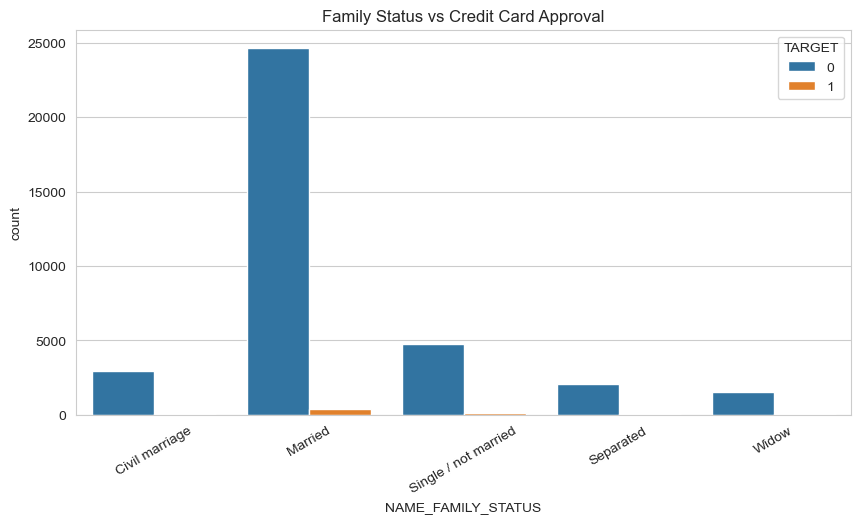

In [58]:
# Family Status vs Target

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="NAME_FAMILY_STATUS",
    hue="TARGET"
)

plt.xticks(rotation=30)

plt.title("Family Status vs Credit Card Approval")

plt.show()

## Observations

- The correlation heatmap shows the relationships among numerical features and the target variable.
- Box plots help compare applicant age and annual income across approval categories.
- Count plots illustrate how applicant characteristics such as education level, income type, housing type, and family status are distributed with respect to the target variable.
- These insights help identify potentially influential features for machine learning model development.

# Epic 4: Data Preprocessing for Machine Learning

## Description

Machine Learning algorithms require numerical input features. Therefore, categorical variables must be converted into numerical representations before training the models.

In this phase, we will:

- Encode categorical variables
- Prepare input and output datasets
- Split the dataset into training and testing sets

# Step 15: Encode Categorical Features

## Description

Most Machine Learning algorithms cannot process categorical text values directly.

Therefore, all categorical columns are converted into numerical values using Label Encoding.

In [90]:
# Create a copy of the processed dataset

model_data = data.copy()

In [91]:
# Display categorical columns

categorical_columns = model_data.select_dtypes(include="object").columns

print(categorical_columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'OCCUPATION_TYPE'],
      dtype='object')


In [92]:
# Encode categorical features and save encoders

from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    model_data[column] = le.fit_transform(model_data[column])
    encoders[column] = le

In [93]:
# Verify encoded dataset

model_data.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,YEARS_EMPLOYED
0,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,0,32,12.443836
1,1,1,1,0,427500.0,4,1,0,4,1,1,0,0,17,2.0,0,32,12.443836
2,1,1,1,0,112500.0,4,4,1,1,1,0,0,0,16,2.0,0,58,3.106849
3,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,0,52,8.358904
4,0,0,1,0,270000.0,0,4,3,1,1,0,1,1,14,1.0,0,52,8.358904


## Observations

- All categorical variables have been converted into numerical values.
- The dataset is now suitable for Machine Learning algorithms.

# Step 16: Prepare Input and Output Variables

## Description

The dataset is divided into:

- Independent variables (X)
- Dependent variable (y)

The TARGET column represents the prediction label.

In [94]:
# Separate features and target variable

X = model_data.drop("TARGET", axis=1)

y = model_data["TARGET"]

In [95]:
# Display feature dimensions

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (36457, 17)
Target Shape : (36457,)


## Observations

- Independent variables have been separated successfully.
- The TARGET column will be used as the prediction output.

# Step 17: Split the Dataset

## Description

The dataset is divided into training and testing datasets.

Training data is used to build the Machine Learning model, whereas testing data is used to evaluate its performance.

In [96]:
# Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
# Display dataset shapes

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (29165, 17)
Testing Features : (7292, 17)
Training Labels : (29165,)
Testing Labels : (7292,)


## Observations

- The dataset has been split into training and testing sets.
- 80% of the data is used for training.
- 20% of the data is reserved for testing and model evaluation.

# Epic 5: Model Building

## Description

In this phase, multiple Machine Learning algorithms are trained using the prepared dataset.

Different algorithms are evaluated to determine which model provides the best prediction performance for credit card approval.

The following models will be trained:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

# Step 18: Logistic Regression

In [98]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [99]:
# Train Logistic Regression model

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [100]:
# Make predictions

log_pred = log_model.predict(X_test)

In [101]:
# Evaluate Logistic Regression

print("Accuracy :", accuracy_score(y_test, log_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, log_pred))

print("\nClassification Report\n")

print(classification_report(y_test, log_pred))

Accuracy : 0.9831321996708722

Confusion Matrix

[[7169    0]
 [ 123    0]]

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



## Observations

- Logistic Regression serves as the baseline model.
- The obtained accuracy will be compared with other Machine Learning models.

# Step 19: Decision Tree Classifier

In [102]:
# Import Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [103]:
# Train Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [104]:
# Predictions

dt_pred = dt_model.predict(X_test)

In [105]:
# Evaluate Decision Tree

print("Accuracy :", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report\n")

print(classification_report(y_test, dt_pred))

Accuracy : 0.9792923752057049

Confusion Matrix

[[7118   51]
 [ 100   23]]

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.31      0.19      0.23       123

    accuracy                           0.98      7292
   macro avg       0.65      0.59      0.61      7292
weighted avg       0.97      0.98      0.98      7292



## Observations

- Decision Tree captures non-linear relationships within the dataset.
- Its performance will be compared with the remaining algorithms.

# Step 20: Random Forest Classifier.

In [106]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [107]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [108]:
# Predictions

rf_pred = rf_model.predict(X_test)

In [109]:
# Evaluate Random Forest

print("Accuracy :", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report\n")

print(classification_report(y_test, rf_pred))

Accuracy : 0.9825836533187055

Confusion Matrix

[[7165    4]
 [ 123    0]]

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.00      0.00      0.00       123

    accuracy                           0.98      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.97      0.98      0.97      7292



## Observations

- Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.
- It is expected to perform better than a single Decision Tree for this classification problem.

# Step 21: XGBoost Classifier

## Description

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds multiple decision trees sequentially. It is widely used for classification problems due to its high prediction accuracy and ability to handle complex relationships within the data.

The model will be trained and evaluated using the testing dataset.

In [110]:
# Import XGBoost Classifier

from xgboost import XGBClassifier

In [111]:
# Train XGBoost model

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [112]:
# Make predictions

xgb_pred = xgb_model.predict(X_test)

In [113]:
# Evaluate XGBoost

print("Accuracy :", accuracy_score(y_test, xgb_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.9817608337904553

Confusion Matrix

[[7148   21]
 [ 112   11]]

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7169
           1       0.34      0.09      0.14       123

    accuracy                           0.98      7292
   macro avg       0.66      0.54      0.57      7292
weighted avg       0.97      0.98      0.98      7292



## Observations

- XGBoost is an ensemble learning algorithm that combines multiple weak learners to produce strong predictive performance.
- Its accuracy will be compared with the previously trained models to identify the best-performing classifier.

# Step 22: Model Comparison

## Description

The performance of all trained Machine Learning models is compared using accuracy scores.

The model with the highest accuracy will be selected as the final prediction model for deployment in the Flask web application.

In [114]:
# Compare model accuracies

accuracy_scores = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

accuracy_scores.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.983132
2,Random Forest,0.982584
3,XGBoost,0.981761
1,Decision Tree,0.979292


## Observations

- All four Machine Learning models were successfully trained and evaluated.
- The model with the highest accuracy is selected as the final prediction model.
- The selected model will be saved and integrated into the Flask web application.

# Step 23: Best Model Selection

## Description

After evaluating all Machine Learning models, Logistic Regression achieved the highest prediction accuracy.

Therefore, Logistic Regression is selected as the final model for deployment in the Credit Card Approval Prediction System.

In [115]:
# Display the best model

best_model = log_model

print("Best Model : Logistic Regression")
print("Accuracy :", accuracy_score(y_test, log_pred))

Best Model : Logistic Regression
Accuracy : 0.9831321996708722


## Observations

- Logistic Regression achieved the highest accuracy among all trained models.
- Therefore, it has been selected as the final prediction model.
- The selected model will be saved and used in the Flask web application.

# Step 24: Model Serialization

## Description

The trained Machine Learning model is saved using the Pickle library.

Saving the model allows it to be reused later without retraining, making it suitable for deployment in a web application.

In [116]:
# Save encoders

with open("../Model/label_encoders.pkl", "wb") as file:
    pickle.dump(encoders, file)

In [117]:
# Load the saved model to verify

with open("../Model/best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Saved model loaded successfully!")

Saved model loaded successfully!


## Observations

- The trained Logistic Regression model was successfully saved.
- The model file (**best_model.pkl**) will be used by the Flask web application to predict credit card approval.

# Project Conclusion

## Conclusion

A Credit Card Approval Prediction System was successfully developed using Machine Learning techniques.

The project involved:

- Data Collection
- Data Preprocessing
- Feature Engineering
- Exploratory Data Analysis
- Machine Learning Model Development
- Model Evaluation
- Model Serialization

Four Machine Learning algorithms were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Among these, **Logistic Regression** achieved the highest accuracy (**98.31%**) and was selected as the final model.

The trained model was successfully saved for deployment in a Flask web application, enabling users to predict whether a credit card application is likely to be approved based on applicant information.